# Notebook \#4: Anomaly Detection
#### by Sebastian Einar Salas Røkholt

---


**Index**  
- [**1 - Introduction and Setup**](#1---introduction)  
  - [*1.1 Setup*](#11-setup)  
  - [*1.2 Load the Anomaly Detection Model*](#12-load-the-anomaly-detection-model)  
  - [*1.3 Data Preparation*](#13-data-preparation)  
- [**2 - Running Anomaly Detection**](#2---running-anomaly-detection)  
  - [*2.1 Classifying a Single Charging Session*](#21-classifying-a-single-charging-session)  
  - [*2.2 Anomaly Detection on the Test Set*](#22-calculating-anomaly-statistics) 
- [**3 - Plotting Anomalies**](#3---plotting-anomalies)  
  - [*3.1 Interactive Anomaly Plot*](#31-interactive-anomaly-plot)

---

## 1 - Introduction and Setup
write an introduction here

### 1.1 Setup

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import Layout
from IPython.display import display, clear_output
import torch
from mt4xai.models import MultiHorizonLSTM
from mt4xai.plot import plot_full_session
from mt4xai.data import make_bundle_from_session, get_session_from_loader, split_data, \
                        fit_scalers_on_train, apply_scalers, build_loader
from mt4xai.ad import compute_session_MRMSE, compute_session_RWSE, fit_rwse_robust_scalers, \
                      classify_by_threshold, percentile_threshold, percentile_of_threshold

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
CLEANED_DATA_PATH = os.path.join(PROJECT_ROOT, "Data", "etron55-charging-sessions.parquet")

FINAL_MODEL_FOLDER_PATH = os.path.join(PROJECT_ROOT, "Models/final")
FINAL_MODEL_PATH = os.path.join(FINAL_MODEL_FOLDER_PATH, "final_model.pth")

PCT_THRESHOLD = 95.0  # Percentile for anomaly detection threshold
T_MIN_EVAL = 1  # Only evaluate and plot predictions for t >= T_MIN_EVAL + 1

print("[env] CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("[env] Device:", torch.cuda.get_device_name(torch.cuda.current_device()))
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

%matplotlib inline

[env] CUDA available: True
[env] Device: NVIDIA GeForce RTX 4070 Laptop GPU


### 1.2 Load the Anomaly Detection Model

In [2]:
# Load the model
def load_final_model(path, device="cpu"):
    checkpoint = torch.load(path, map_location=device)
    cfg = checkpoint["config"]
    model = MultiHorizonLSTM(
        input_size=len(checkpoint["input_features"]),
        hidden_size=int(cfg["hidden_dim"]),
        horizon=cfg["horizon"],
        num_targets=len(checkpoint["target_features"]),
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"]
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint

model, checkpoint = load_final_model(FINAL_MODEL_PATH, device=DEVICE)

input_features  = checkpoint["input_features"]
target_features = checkpoint["target_features"]
cfg             = checkpoint["config"]
HORIZON         = int(cfg["horizon"])
POWER_WEIGHT    = float(cfg.get("power_weight", 0.5))

# Indices of targets within the *input* feature vector (used for reconstruction)
idx_power_inp = input_features.index("power")
idx_soc_inp   = input_features.index("soc")


/tmp/ipykernel_9736/2667936666.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


### 1.3 Data Preparation
In this section, we will load, transform, and split the data in exactly the same way as we did previously in order to extract the test set for running anomaly detection tests.

In [3]:
# Loads the cleaned data (already wrangled)
df_cleaned = pd.read_parquet(CLEANED_DATA_PATH)  # TODO: Replace with raw data and apply wrangling pipeline
df = df_cleaned.copy()

# Split exactly like the modelling notebook (GroupShuffleSplit + RANDOM_SEED)
train_df, val_df, test_df = split_data(df, test_size=0.2, validation_size=0.1)

# Fit scalers on train and apply to val/test (same as modelling)
cols_to_scale = list(set(input_features) | set(target_features))
scalers = fit_scalers_on_train(train_df, cols_to_scale)
power_scaler, soc_scaler = scalers["power"], scalers["soc"]  # Extract for later use
train_s = apply_scalers(train_df, scalers)
val_s   = apply_scalers(val_df, scalers)
test_s  = apply_scalers(test_df, scalers)

# Builds the DataLoaders to iterate over charging sessions
val_loader  = build_loader(val_s,  input_features, target_features, HORIZON, batch_size=16, shuffle=False, num_workers=0)
test_loader = build_loader(test_s, input_features, target_features, HORIZON, batch_size=16, shuffle=False, num_workers=0)

## 2 - Running Anomaly Detection

### 2.1 Classifying a Single Charging Session
In this section, we compute the Macro-RMSE and RWSE of a single charging session and classify it as normal or abnormal. 
The classification threshold for each error metric is arbitrarily chosen. 

In [4]:
# Specifying session by batch + sample index within test set
sid, X, Y, L = get_session_from_loader(test_loader, session_idx=0, batch_idx=0)
sid_list = [sid]

# Computes Macro-RMSE
session_mrse = compute_session_MRMSE(
    model, [(sid_list, X, Y, L)], DEVICE,
    power_scaler, soc_scaler, POWER_WEIGHT,
    idx_power_inp, idx_soc_inp, T_MIN_EVAL
).error.iloc[0]

# Computes RWSE by fitting robust scalers on validation set
m_rwse, mad_rwse = fit_rwse_robust_scalers(
    model, val_s, device=DEVICE, input_features=input_features, target_features=target_features,
    horizon=HORIZON, power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp, t_min_eval=T_MIN_EVAL,
    cache_key=f"H{HORIZON}_t{T_MIN_EVAL}"
)

session_rwse = compute_session_RWSE(
    model, session_ids=[sid], df_scaled=test_s, device=DEVICE, input_features=input_features, 
    target_features=target_features, power_scaler=power_scaler, soc_scaler=soc_scaler, 
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp, m=m_rwse, mad=mad_rwse,
    horizon=HORIZON, horizon_weights_decay=0.4, 
    t_min_eval=T_MIN_EVAL).error.iloc[0]

# Setting arbitrarily chosen error thresholds for each metric
mrmse_thr = 10.0
rwse_thr = 3.0

mrmse_label = "ABNORMAL" if session_mrse > mrmse_thr else "NORMAL"
rwse_label = "ABNORMAL" if session_rwse > rwse_thr else "NORMAL"

print(f"Anomaly detection on session {sid}:")
print(f"Macro-RMSE = {session_mrse:.3f}, Macro-RMSE AD threshold = {mrmse_thr:.3f} ---> Classification = {mrmse_label}")
print(f"RWSE = {session_rwse:.3f}, RWSE AD threshold = {rwse_thr:.3f} ---> Classification = {rwse_label}")

Anomaly detection on session 5128923:
Macro-RMSE = 1.007, Macro-RMSE AD threshold = 10.000 ---> Classification = NORMAL
RWSE = 3.068, RWSE AD threshold = 3.000 ---> Classification = ABNORMAL


In [5]:
# Classify by explicit session_id
sid, X2, Y2, L2 = get_session_from_loader(test_loader, session_id=1691162)

# Computes Macro-RMSE
session_mrse = compute_session_MRMSE(
    model, [(sid_list, X, Y, L)], DEVICE,
    power_scaler, soc_scaler, POWER_WEIGHT,
    idx_power_inp, idx_soc_inp, T_MIN_EVAL
).error.iloc[0]

# Computes RWSE by fitting robust scalers on validation set
m_rwse, mad_rwse = fit_rwse_robust_scalers(
    model, val_s, device=DEVICE, input_features=input_features, target_features=target_features,
    horizon=HORIZON, power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp, t_min_eval=T_MIN_EVAL,
    cache_key=f"H{HORIZON}_t{T_MIN_EVAL}"
)

session_rwse = compute_session_RWSE(
    model, session_ids=[sid], df_scaled=test_s, device=DEVICE, input_features=input_features, 
    target_features=target_features, power_scaler=power_scaler, soc_scaler=soc_scaler, 
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp, m=m_rwse, mad=mad_rwse,
    horizon=HORIZON, horizon_weights_decay=0.4, 
    t_min_eval=T_MIN_EVAL).error.iloc[0]

# Setting arbitrarily chosen error thresholds for each metric
mrmse_thr = 10.0
rwse_thr = 3.0

mrmse_label = "ABNORMAL" if session_mrse > mrmse_thr else "NORMAL"
rwse_label = "ABNORMAL" if session_rwse > rwse_thr else "NORMAL"

print(f"Anomaly detection on session {sid}:")
print(f"Macro-RMSE = {session_mrse:.3f}, Macro-RMSE AD threshold = {mrmse_thr:.3f} ---> Classification = {mrmse_label}")
print(f"RWSE = {session_rwse:.3f}, RWSE AD threshold = {rwse_thr:.3f} ---> Classification = {rwse_label}")

Anomaly detection on session 1691162:
Macro-RMSE = 1.007, Macro-RMSE AD threshold = 10.000 ---> Classification = NORMAL
RWSE = 1.488, RWSE AD threshold = 3.000 ---> Classification = NORMAL


### 2.2 Anomaly Detection on the Test Set
In order to determine an appropriate classification threshold for each metric, we first calculate the distribution of errors of the validation set and all errors of the test set. To classify the sessions in the test set, we set the classification threshold to the nth percentile of errors for the validation set. In this section, we will classify all sessions in the test set based on an arbitrarily selected percentile threshold (95th percentile).

#### 2.2.1 Computing Macro-RMSE and RWSE

**Macro Root Mean Squared Error (Macro-RMSE)**</br>

Given predictions $(\hat{y}_{t,h,c})$ and true values $(y_{t,h,c})$, where $(t)$ indexes time, $(h \in \{1,\dots,H\})$ is the prediction horizon, and $(c \in \{1,2\})$ denotes the target variables (power, SOC), the per-horizon-channel RMSE is:

$$
\text{RMSE}_{h,c} = \sqrt{ \frac{1}{T_{h,c}} \sum_{t=1}^{T_{h,c}} \big( y_{t,h,c} - \hat{y}_{t,h,c} \big)^2 }
$$

The session-level Macro-RMSE is then:

$$
\text{MacroRMSE} = \frac{1}{H} \sum_{h=1}^{H} \Big( w \cdot \text{RMSE}_{h,\text{power}} + (1-w) \cdot \text{RMSE}_{h,\text{soc}} \Big)
$$

where:
- $H$ = number of horizons  
- $w$ = weight for power (with $(1-w)$ for SOC)  
- $T_{h,c}$ = number of valid timesteps for horizon $h$ and target $c$  


**Robust Weighted Standardized Error (RWSE)** </br>
To calculate the RWSE, we adjust residuals by their median and median absolute deviation (MAD) computed on the validation set, then apply the weights across the prediction horizons and targets.  

The residuals are defined as:

$$
r_{t,h,c} = y_{t,h,c} - \hat{y}_{t,h,c}
$$

For each horizon $h$ and channel $c$, we compute the median $(m_{h,c})$ and median absolute deviation $(\text{MAD}_{h,c})$ from validation residuals. The standardized residuals are then:

$$
z_{t,h,c} = \frac{|\,r_{t,h,c} - m_{h,c}\,|}{\text{MAD}_{h,c}}
$$

with values clipped at a cap (e.g. $z_{t,h,c} \leq 5.0$).  

To combine errors across horizons and targets, we apply the weights:
- Horizon weights $w_h$ (exponential decay, normalized to sum to 1)  
- Target weights $w_c$ (uniform over channels, sum to 1)  

Therefore, the RWSE for a session is:

$$
\text{RWSE} = \frac{1}{T'} \sum_{t=1}^{T'} \sum_{h=1}^{H} \sum_{c=1}^{C} w_h \, w_c \, z_{t,h,c}
$$

where:
- $T'$ = number of evaluated time steps (after $t_{\min}^{eval}$)  
- $H$ = number of horizons  
- $C$ = number of target variables (power, SOC)  



In [6]:
# Macro-RMSE
df_val_err_mrmse = compute_session_MRMSE(model, val_loader, DEVICE, 
                                         power_scaler, soc_scaler, POWER_WEIGHT, 
                                         idx_power_inp, idx_soc_inp, T_MIN_EVAL)

df_test_err_mrmse = compute_session_MRMSE(model, test_loader, DEVICE, power_scaler, 
                                          soc_scaler, POWER_WEIGHT, idx_power_inp, 
                                          idx_soc_inp, T_MIN_EVAL)

# RWSE
m_rwse, mad_rwse = fit_rwse_robust_scalers(
    model, val_s, device=DEVICE, input_features=input_features, target_features=target_features,
    horizon=HORIZON, power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp, t_min_eval=T_MIN_EVAL,
    cache_key=f"H{HORIZON}_t{T_MIN_EVAL}"
)

df_val_err_rwse = compute_session_RWSE(
    model, val_s, device=DEVICE, input_features=input_features, target_features=target_features,
    horizon=HORIZON, horizon_weights_decay=0.4, power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
    m=m_rwse, mad=mad_rwse, cap=5.0, t_min_eval=T_MIN_EVAL
)

df_test_err_rwse = compute_session_RWSE(
    model, test_s, device=DEVICE, input_features=input_features, target_features=target_features,
    horizon=HORIZON, horizon_weights_decay=0.4, power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
    m=m_rwse, mad=mad_rwse, cap=5.0, t_min_eval=T_MIN_EVAL
)


#### 2.2.2 Classifying Charging Sessions
We classify each charging session by labelling it as "abnormal" when the model's prediction error for the session is above the anomaly detection threshold. Sessions below the threshold are labelled as "normal". 

In [14]:
# Classifies sessions in test set
pct_thresh = PCT_THRESHOLD  # Percentile for anomaly detection threshold, e.g. 95.0
 
# with Macro-RMSE at error threshold computed on validation set
mrmse_thr = percentile_threshold(np.sort(df_val_err_mrmse["error"].to_numpy()), pct_thr=pct_thresh)
mrmse_test_cls_df = classify_by_threshold(df_test_err_mrmse, mrmse_thr)

# with RWSE at error threshold computed on validation set
rwse_thr = percentile_threshold(np.sort(df_val_err_rwse["error"].to_numpy()), pct_thr=pct_thresh)
rwse_test_cls_df = classify_by_threshold(df_test_err_rwse, rwse_thr)

print(f"\nClassification counts:\n Macro-RMSE: {mrmse_test_cls_df["label"].value_counts().to_string()}\n \
      RWSE: {rwse_test_cls_df["label"].value_counts().to_string()}")


Classification counts:
 Macro-RMSE: label
normal      11571
abnormal      612
       RWSE: label
normal      11601
abnormal      582


#### 2.2.3 Calculating Anomaly Statistics

In [15]:
# Session lengths
min_session_len = int(mrmse_test_cls_df["length"].min())
max_session_len = int(mrmse_test_cls_df["length"].max())

# Macro-RMSE metric stats
all_mrmse = mrmse_test_cls_df["error"].to_numpy()
all_mrsmse_sorted = np.sort(all_mrmse)
mrmse_min_err, mrmse_max_err = float(all_mrsmse_sorted[0]), float(all_mrsmse_sorted[-1])


# Global y-limit for power (kept for plotting UI)
power_y_lim = (
    0.0,
    float(power_scaler.inverse_transform(test_s[["power"]].to_numpy(np.float32)).max())
)

print(f"Macro_RMSE threshold @ {pct_thresh:.1f}th pct = {mrmse_thr:.4f}")
print(f"RWSE threshold @ {pct_thresh:.1f}th pct = {rwse_thr:.4f}")
print(f"\nLowest-RMSE (most normal) sessions:\n{mrmse_test_cls_df.sort_values("error").head(5)}")
print(f"\nHighest-RMSE (most abnormal) sessions:\n{mrmse_test_cls_df.sort_values("error", ascending=False).head(3)}")
print(f"\nError ranges: Macro-RMSE ∈ [{mrmse_min_err:.3f}, {mrmse_max_err:.3f}], ...")
print(f"Session length range: [{min_session_len}, {max_session_len}] time steps")
print(f"Max power output: {power_y_lim[1]:.1f} kW")


Macro_RMSE threshold @ 95.0th pct = 9.6530
RWSE threshold @ 95.0th pct = 2.8567

Lowest-RMSE (most normal) sessions:
   charging_id     error  length   label
0     10303976  0.118043      10  normal
1     11935991  0.136369      10  normal
2      7080318  0.146011      12  normal
3      1972288  0.151608      12  normal
4      8882402  0.160326      12  normal

Highest-RMSE (most abnormal) sessions:
       charging_id      error  length     label
12182     11732342  67.532005      15  abnormal
12181      1836322  47.172943      15  abnormal
12180     11156542  38.277706      17  abnormal

Error ranges: Macro-RMSE ∈ [0.118, 67.532], ...
Session length range: [8, 60] time steps
Max power output: 199.6 kW


To better understand the baseline error levels and to set anomaly thresholds,
we visualize the distribution of Macro-RMSE and RWSE on the validation set. The histogram and Kernel Density Estimation (KDE) for each distribution is shown on the same plot, along with the selected thresholds. 

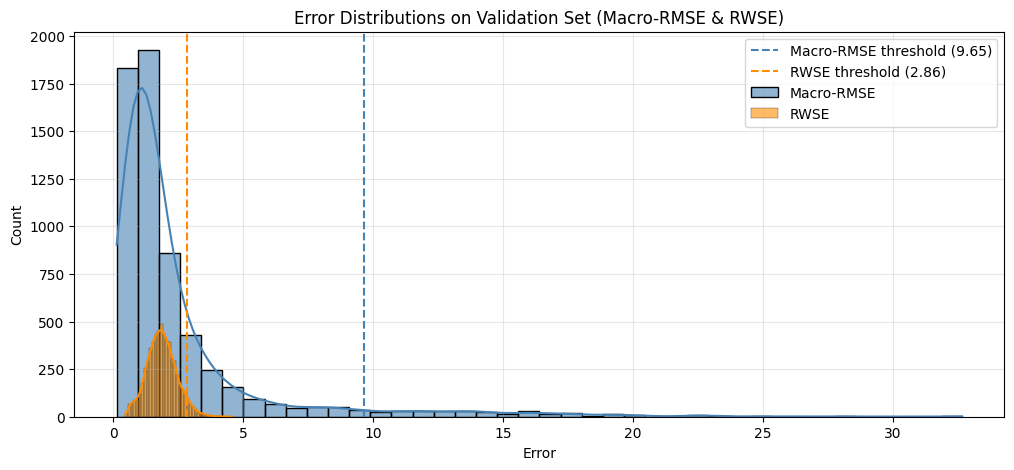

In [17]:
plt.figure(figsize=(12,5))

# Macro-RMSE distribution
sns.histplot(df_val_err_mrmse["error"], kde=True, bins=40, color="steelblue", alpha=0.6, label="Macro-RMSE")

# RWSE distribution
sns.histplot(df_val_err_rwse["error"], kde=True, bins=40, color="darkorange", alpha=0.6, label="RWSE")

plt.axvline(mrmse_thr, color="steelblue", linestyle="--", linewidth=1.5, label=f"Macro-RMSE threshold ({mrmse_thr:.2f})")
plt.axvline(rwse_thr, color="darkorange", linestyle="--", linewidth=1.5, label=f"RWSE threshold ({rwse_thr:.2f})")

plt.xlabel("Error")
plt.ylabel("Count")
plt.title("Error Distributions on Validation Set (Macro-RMSE & RWSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3 - Plotting Anomalies

### 3.1 Interactive Anomaly Plot

In [ ]:
ERR_TABLES = {
    "macro_rmse": {"val": df_val_err_mrmse, "test": df_test_err_mrmse, "label": "Macro-RMSE"},
    "rwse": {"val": df_val_err_rwse,  "test": df_test_err_rwse,  "label": "RWSE"},
}

def choose_metric_tables(metric_key: str):
    if metric_key not in ERR_TABLES:
        raise ValueError(f"Unknown metric: {metric_key}")
    d = ERR_TABLES[metric_key]
    return d["val"].copy(), d["test"].copy(), d["label"]

df_val_err, df_test_errs, METRIC_LABEL = choose_metric_tables("macro_rmse")


# Caching for faster loading of previously viewed sessions
BUNDLE_CACHE = {}
def get_bundle(session_id):
    key = ("sid", int(session_id))
    if key not in BUNDLE_CACHE:
        BUNDLE_CACHE[key] = make_bundle_from_session(
            model=model, df_scaled=test_s, sid=int(session_id), device=DEVICE,
            input_features=input_features, target_features=target_features, horizon=HORIZON,
            power_scaler=power_scaler, soc_scaler=soc_scaler,
            idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
            sort_by="minutes_elapsed"
        )
    return BUNDLE_CACHE[key]


# Widgets
w_metric = widgets.ToggleButtons(
    options=[("Macro-RMSE", "macro_rmse"), ("RWSE", "rwse")],
    value="macro_rmse", description="Metric", layout=Layout(width="100%")
)
w_cls = widgets.ToggleButtons(
    options=[("Normal", "normal"), ("Abnormal", "abnormal")],
    value="abnormal", description="Classification", layout=Layout(width="100%")
)

w_target = widgets.SelectMultiple(
    options=["power", "soc"], value=("power", "soc"),
    description="Plot Target", rows=2)
w_target.layout = Layout(width="60%")

w_idx = widgets.IntSlider(value=0, min=0, max=0, step=1, description="Index",
                          continuous_update=False, layout=Layout(width="100%"))
w_len = widgets.IntRangeSlider(
    value=[min_session_len, max_session_len],
    min=min_session_len, max=max_session_len, step=1,
    description="Length ∈", continuous_update=False, layout=Layout(width="100%")
)
w_err = widgets.FloatRangeSlider(
    value=[mrmse_min_err, mrmse_max_err], min=mrmse_min_err, max=mrmse_max_err,
    step=(mrmse_max_err-mrmse_min_err)/500.0, description="Error ∈",
    readout_format=".2f", continuous_update=False, layout=Layout(width="80%")
)

w_thr = widgets.FloatSlider(
    value=mrmse_thr, min=mrmse_min_err, max=mrmse_max_err,
    step=(mrmse_max_err-mrmse_min_err)/300.0, description="Classification Threshold",
    readout_format=".3f", continuous_update=False, 
    layout=Layout(width="70%"), style={"description_width": "initial"}
)

w_thr_pct = widgets.HTML(value=f"<b>{percentile_of_threshold(all_mrsmse_sorted, w_thr.value):.1f}th</b> percentile")

sid_options = list(map(str, sorted(mrmse_test_cls_df["charging_id"].unique())))
w_sid = widgets.Combobox(
    placeholder="Jump to session id…",
    options=sid_options,
    value="",
    description="Session",
    ensure_option=False,
    layout=Layout(width="100%")
)

w_reset = widgets.Button(description="Reset filters", icon="refresh", button_style="", layout=Layout(width="100%"))
out = widgets.Output()

# ---------- Metric switching ----------
def _set_globals_for_metric(metric_key):
    global df_val_err, df_test_errs, METRIC_LABEL, mrmse_thr
    global all_rmse_errs, all_mrsmse_sorted, mrmse_min_err, mrmse_max_err
    global min_session_len, max_session_len

    df_val_err, df_test_errs, METRIC_LABEL = choose_metric_tables(metric_key)
    val_sorted = np.sort(df_val_err["error"].to_numpy())
    mrmse_thr = percentile_threshold(val_sorted, pct_thr=PCT_THRESHOLD)

    all_rmse_errs = df_test_errs["error"].to_numpy()
    all_mrsmse_sorted = np.sort(all_rmse_errs)
    mrmse_min_err = float(all_mrsmse_sorted[0]); mrmse_max_err = float(all_mrsmse_sorted[-1])
    min_session_len = int(df_test_errs["length"].min()); max_session_len = int(df_test_errs["length"].max())

# ---------- Filtering helpers ----------
def filtered_df(cls_label, thr, len_lo, len_hi, err_lo, err_hi):
    df = df_test_errs[
        (df_test_errs["length"] >= len_lo) & (df_test_errs["length"] <= len_hi) &
        (df_test_errs["error"]  >= err_lo) & (df_test_errs["error"]  <= err_hi)
    ].copy()
    df["label"] = np.where(df["error"] > thr, "abnormal", "normal")
    df = df[df["label"] == cls_label]
    df = df.sort_values("error", ascending=(cls_label == "normal")).reset_index(drop=True)
    return df

def update_index_range(*_):
    df = filtered_df(w_cls.value, w_thr.value, w_len.value[0], w_len.value[1],
                     w_err.value[0], w_err.value[1])
    n = len(df)
    w_idx.max = max(0, n - 1)
    w_thr_pct.value = f"<b>{percentile_of_threshold(all_mrsmse_sorted, w_thr.value):.1f}th</b> percentile"
    render_plots()

def _jump_to_sid(*_):
    sid_str = (w_sid.value or "").strip()
    if not sid_str.isdigit():
        return
    sid = int(sid_str)

    df = filtered_df(w_cls.value, w_thr.value, w_len.value[0], w_len.value[1],
                     w_err.value[0], w_err.value[1])
    
    pos = np.where(df["charging_id"].to_numpy() == sid)[0]
    if len(pos):
        w_idx.value = int(pos[0])


def _reset_filters(_btn=None):
    w_len.value = [min_session_len, max_session_len]
    w_err.value = [mrmse_min_err, mrmse_max_err]
    w_thr.value = mrmse_thr
    w_idx.value = 0
    w_sid.value = ""
    update_index_range()

# ---------- Rendering ----------
def render_plots(*_):
    df = filtered_df(w_cls.value, w_thr.value, w_len.value[0], w_len.value[1],
                     w_err.value[0], w_err.value[1])
    n = len(df)
    with out:
        clear_output(wait=True)
        if n == 0:
            print(f"[{METRIC_LABEL}] No sessions match the current filter.")
            return
        row = df.iloc[min(w_idx.value, n-1)]
        sid, err, lbl = row["charging_id"], float(row["error"]), row["label"]
        bundle = get_bundle(sid)
        for tgt in list(w_target.value):
            y_lim = power_y_lim if tgt == "power" else (0.0, 100.0)
            plot_full_session(bundle, power_scaler, soc_scaler,
                            idx_power_inp, idx_soc_inp,
                            t_min_eval=T_MIN_EVAL, target=tgt,
                            error=err, threshold=w_thr.value, label=lbl,
                            figsize=(10, 5), dpi=300,
                            y_lim=y_lim)
        print(f"[{METRIC_LABEL}] {n} sessions match filters — Index {w_idx.value+1}/{n}")

# ---------- Observers ----------
def _on_metric_change(change):
    if change["name"] == "value":
        _set_globals_for_metric(change["new"])
        # retune ranges for selected metric
        w_len.min = min_session_len; w_len.max = max_session_len
        w_len.value = [min_session_len, max_session_len]

        w_err.min = mrmse_min_err; w_err.max = mrmse_max_err
        w_err.step = (mrmse_max_err-mrmse_min_err)/500.0 if mrmse_max_err > mrmse_min_err else 1e-3
        w_err.value = [mrmse_min_err, mrmse_max_err]

        w_thr.min = mrmse_min_err; w_thr.max = mrmse_max_err
        w_thr.step = (mrmse_max_err-mrmse_min_err)/500.0 if mrmse_max_err > mrmse_min_err else 1e-3
        w_thr.value = mrmse_thr
        _reset_filters()

w_metric.observe(_on_metric_change, names="value")
for w in (w_cls, w_thr, w_len, w_err): w.observe(update_index_range, names="value")
for w in (w_idx, w_target): w.observe(render_plots, names="value")
w_sid.observe(_jump_to_sid, names="value")
w_reset.on_click(_reset_filters)

# 3 column layout
col1 = widgets.VBox([w_cls, w_target], layout=Layout(width="20%"))
col2 = widgets.VBox([w_idx, w_len], layout=Layout(width="25%"))
col3 = widgets.VBox([w_metric, w_err, widgets.HBox([w_thr, w_thr_pct])], layout=Layout(width="35%"))
col4 = widgets.VBox([w_reset], layout=Layout(width="10%"))

top_row = widgets.HBox([col1, col2, col3, col4], layout=Layout(width="100%", justify_content="space-between", align_items="flex-start"))
ui = widgets.VBox([top_row, out], layout=Layout(width="100%"))

# Render initial plots
_set_globals_for_metric
update_index_range()
display(ui)
